# Spotify Music Recommendation System Using Audio Features

## Latar Belakang
Platform streaming musik seperti Spotify menyediakan jutaan lagu dari berbagai genre. Banyaknya pilihan tersebut sering membuat pengguna kesulitan menemukan lagu baru yang sesuai dengan selera mereka. Oleh karena itu, diperlukan **Recommendation System** untuk membantu pengguna menemukan musik yang relevan.

Pada proyek ini digunakan pendekatan **Content-Based Filtering**, yaitu metode yang merekomendasikan lagu berdasarkan kemiripan karakteristiknya. Dataset Spotify menyediakan berbagai **audio features** seperti danceability, energy, loudness, tempo, dan valence yang merepresentasikan karakteristik musik dari setiap lagu.

## Tujuan Proyek
Tujuan proyek ini adalah membangun **Music Recommendation System** yang dapat merekomendasikan lagu berdasarkan kemiripan karakteristik audio menggunakan metode **Cosine Similarity**.

## Import Libraries

In [270]:
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

# Setting visualisasi
sns.set_style(style='white')
# Konfigurasi default plot
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [271]:
df = pd.read_csv("dataset.csv")
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [272]:
df.shape

(114000, 21)

In [273]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='object')

## Data Understanding

In [274]:
missing_values = df.isnull().sum()

missing_values.sum()

np.int64(3)

In [275]:
df = df.dropna()
df = df.drop(columns=["Unnamed: 0"])

In [276]:
df.duplicated().sum()

np.int64(450)

In [277]:
# menghapus data duplikat berdasarkan dua kolom agar merekomendasikan lagu yang berbeda
# ada kasus dimana satu lagu memiliki berbagai genre
df = df.drop_duplicates(subset=["track_name", "artists"])
df = df.reset_index(drop=True)

In [278]:
# Melihat statistik deskriptif fitur numerik
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,81343.000000,8.134300e+04,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000
mean,34.636392,2.314145e+05,0.559276,0.635025,5.285900,-8.593930,0.632347,0.088993,0.329666,0.184733,0.219723,0.463277,122.144834,3.896967
std,19.438517,1.164924e+05,0.177747,0.258641,3.557629,5.304797,0.482169,0.116629,0.339961,0.331592,0.198272,0.263383,30.129012,0.456398
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21.000000,1.738710e+05,0.446000,0.455000,2.000000,-10.451500,0.000000,0.036100,0.015900,0.000000,0.098500,0.241000,99.408000,4.000000
50%,35.000000,2.152050e+05,0.573000,0.678000,5.000000,-7.262000,1.000000,0.049100,0.190000,0.000089,0.133000,0.449000,122.030000,4.000000
75%,49.000000,2.673460e+05,0.690000,0.857000,8.000000,-5.140000,1.000000,0.087000,0.629000,0.153000,0.283000,0.676000,140.128500,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [279]:
# Melihat statistik kolom kategorikal
df.describe(include="object")

,track_id,artists,album_name,track_name,track_genre
count,81343,81343,81343,81343,81343
unique,81343,31437,45094,73608,113
top,2hETkH7cOfqmz3LqZDHZf5,George Jones,The Complete Hank Williams,Home,study
freq,1,215,94,24,996


In [280]:
# Melihat jumlah genre unik
df["track_genre"].nunique()

113

In [281]:
# Melihat beberapa genre yang ada
df["track_genre"].unique()[:20]

array(['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient',
       'anime', 'black-metal', 'bluegrass', 'blues', 'brazil',
       'breakbeat', 'british', 'cantopop', 'chicago-house', 'children',
       'chill', 'classical', 'club', 'comedy', 'country'], dtype=object)

## EDA

In [282]:
# Definisikan fitur audio yang akan dianalisis
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

# Statistik deskriptif fitur audio
display(df[audio_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
danceability,81343.0,0.559276,0.177747,0.000,0.4460,0.573000,0.6900,0.985
energy,81343.0,0.635025,0.258641,0.000,0.4550,0.678000,0.8570,1.000
loudness,81343.0,-8.593930,5.304797,-49.531,-10.4515,-7.262000,-5.1400,4.532
speechiness,81343.0,0.088993,0.116629,0.000,0.0361,0.049100,0.0870,0.965
acousticness,81343.0,0.329666,0.339961,0.000,0.0159,0.190000,0.6290,0.996
instrumentalness,81343.0,0.184733,0.331592,0.000,0.0000,0.000089,0.1530,1.000
liveness,81343.0,0.219723,0.198272,0.000,0.0985,0.133000,0.2830,1.000
valence,81343.0,0.463277,0.263383,0.000,0.2410,0.449000,0.6760,0.995
tempo,81343.0,122.144834,30.129012,0.000,99.4080,122.030000,140.1285,243.372


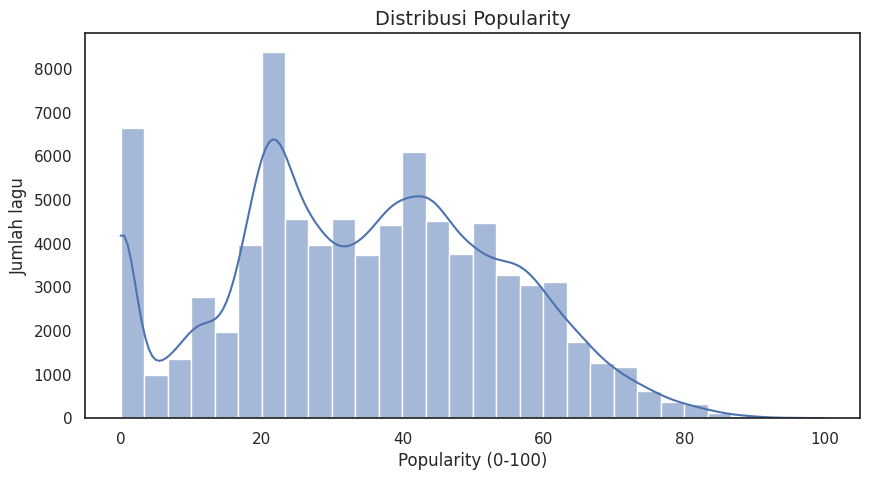

In [283]:
# Distribusi popularity
plt.figure(figsize=(10,5))
sns.histplot(df["popularity"], bins=30, kde=True)
plt.title("Distribusi Popularity")
plt.xlabel("Popularity (0-100)")
plt.ylabel("Jumlah lagu")
plt.show()

terlihat sebenarnya distribusi popularity cukup merata tapi semakin tinggi popularity jumlah lagu semakin sedikit

In [284]:
# Top 10 most popular tracks
top_pop = df.sort_values("popularity", ascending=False).head(10)
display(top_pop[["track_name","artists","track_genre","popularity"]])

,track_name,artists,track_genre,popularity
17152,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
41581,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
51529,La Bachata,Manuel Turizo,latin,98
17159,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
51530,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97
51531,Tití Me Preguntó,Bad Bunny,latin,97
51648,Efecto,Bad Bunny,latin,96
17151,Under The Influence,Chris Brown,dance,96
59742,I Ain't Worried,OneRepublic,piano,96
61256,As It Was,Harry Styles,pop,95


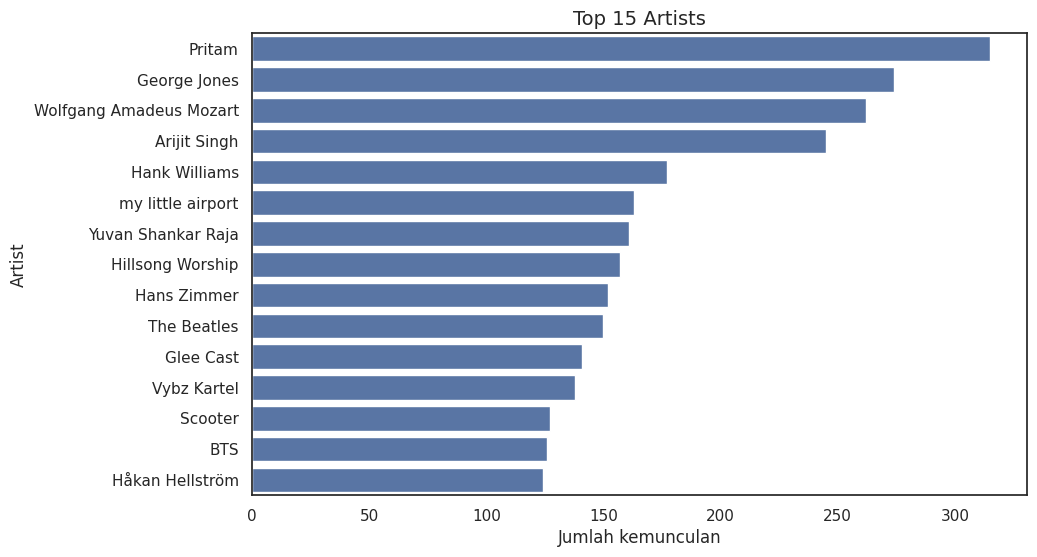

In [285]:
# Top artists (banyak dataset menyimpan banyak artist per field; kita hitung penampilan string artists)
# Jika artists berisi beberapa nama dipisahkan oleh ';', kita split dan hitung individual artist
artists_series = df["artists"].dropna().astype(str)
artists_flat = artists_series.str.split(";").explode().str.strip()
top_artists = artists_flat.value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=top_artists.values, y=top_artists.index)
plt.title("Top 15 Artists")
plt.xlabel("Jumlah kemunculan")
plt.ylabel("Artist")
plt.show()

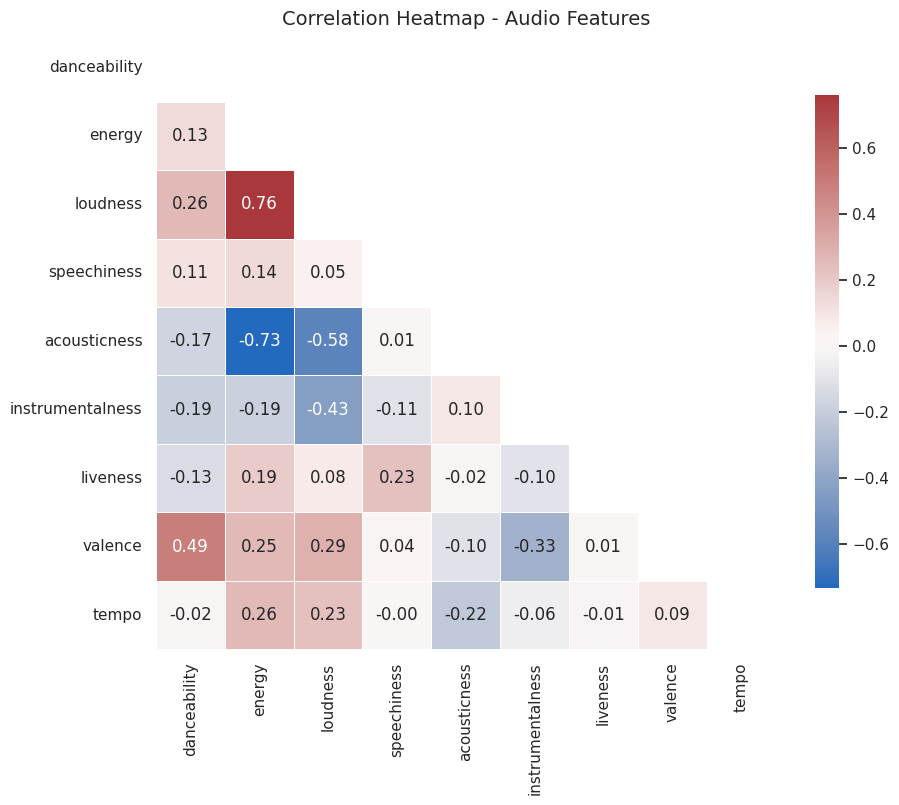

In [286]:
# Korelasi antar fitur audio
corr = df[audio_features].corr()
plt.figure(figsize=(10,8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", mask=mask, linewidths=.5, cbar_kws={"shrink":.8})
plt.title("Correlation Heatmap - Audio Features")
plt.show()

jelas bahwa energy berkorelasi kuat dengan loudness dan energy juga berkorelasi kuat dengan acousticness

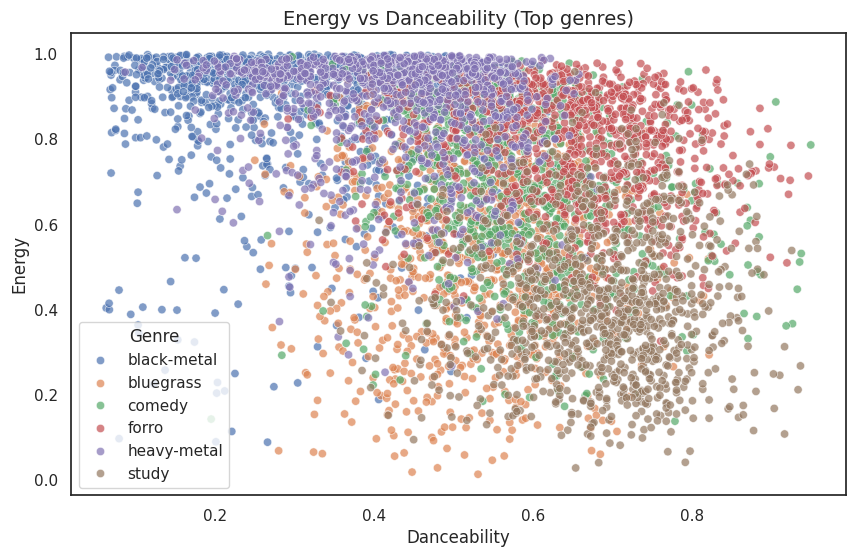

In [287]:
# Scatter plot: Energy vs Danceability, warna berdasarkan genre (hanya top genres untuk keterbacaan)
if "track_genre" in df.columns and "energy" in df.columns and "danceability" in df.columns:
    top_genres_list = df["track_genre"].value_counts().nlargest(6).index.tolist()
    sample = df[df["track_genre"].isin(top_genres_list)].copy()

    plt.figure(figsize=(10,6))
    sns.scatterplot(data=sample, x="danceability", y="energy", hue="track_genre", alpha=0.7)
    plt.title("Energy vs Danceability (Top genres)")
    plt.xlabel("Danceability")
    plt.ylabel("Energy")
    plt.legend(title="Genre")
    plt.show()
else:
    print("Tidak ada kolom yang diperlukan (track_genre, energy, danceability).")

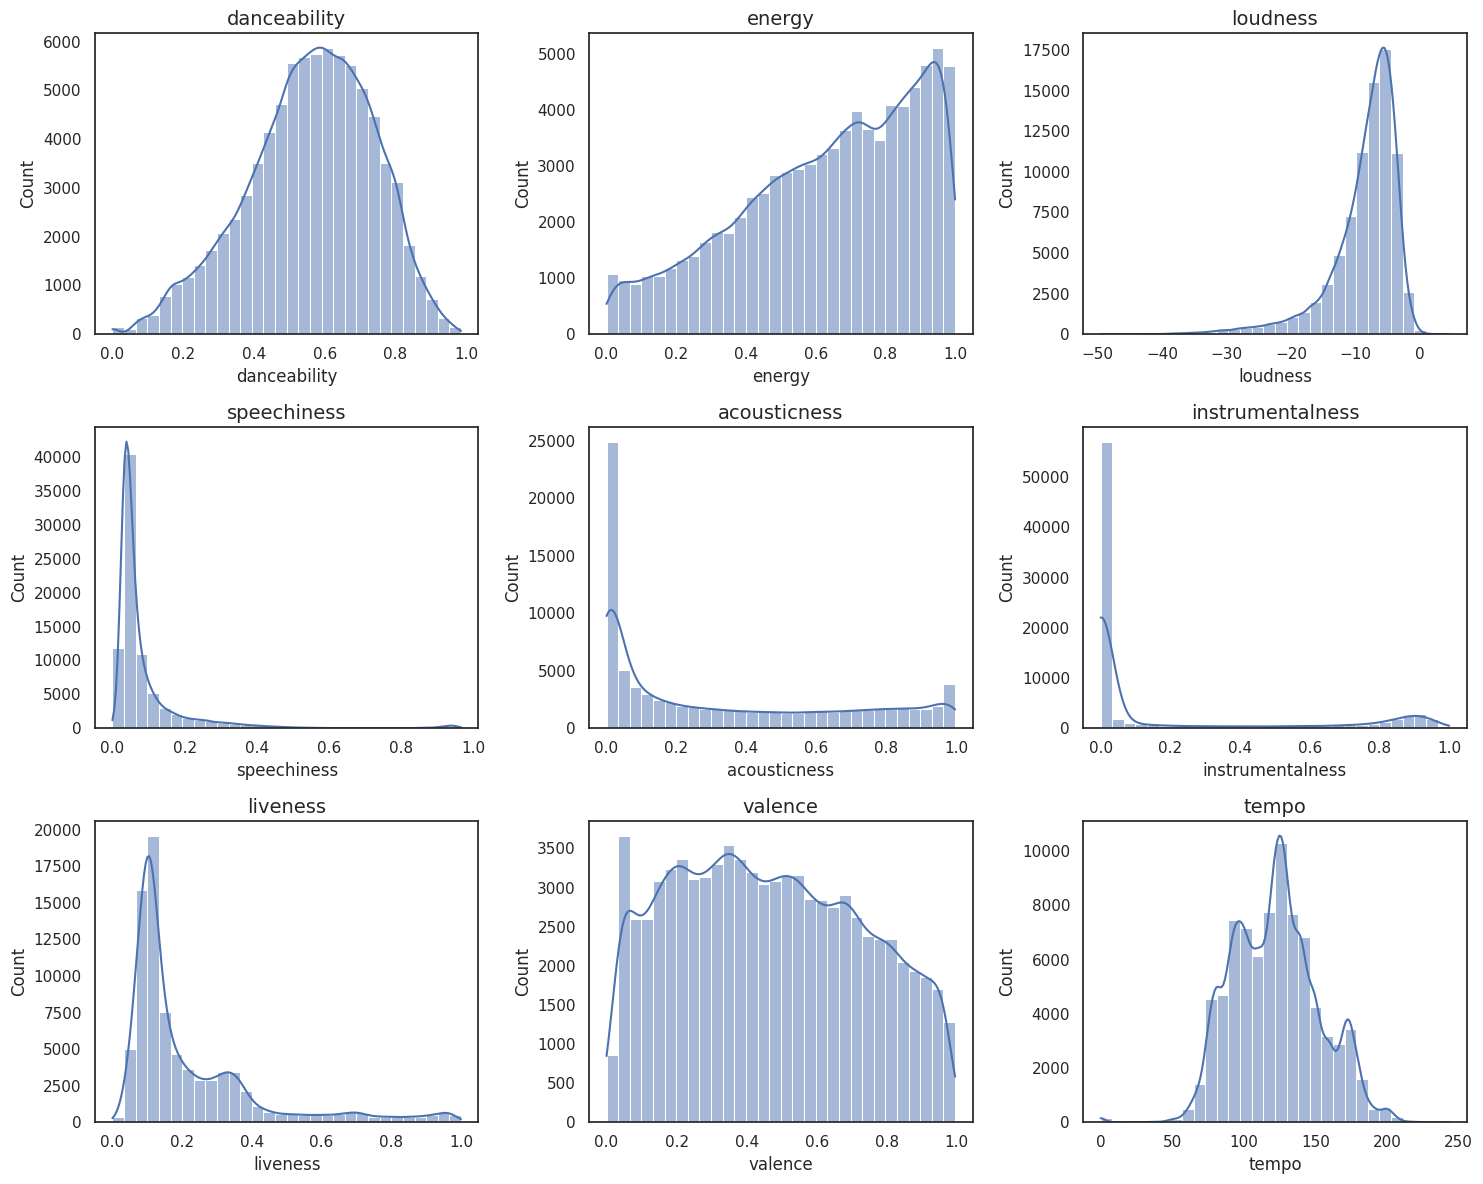

In [288]:
# Distribusi masing-masing fitur audio dalam satu grid (histogram)
n = len(audio_features)
cols = 3
rows = int(np.ceil(n/cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4*rows))
axes = axes.flatten()

for i, feat in enumerate(audio_features):
    sns.histplot(df[feat].dropna(), ax=axes[i], bins=30, kde=True)
    axes[i].set_title(feat)

# kosongkan axes sisa
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

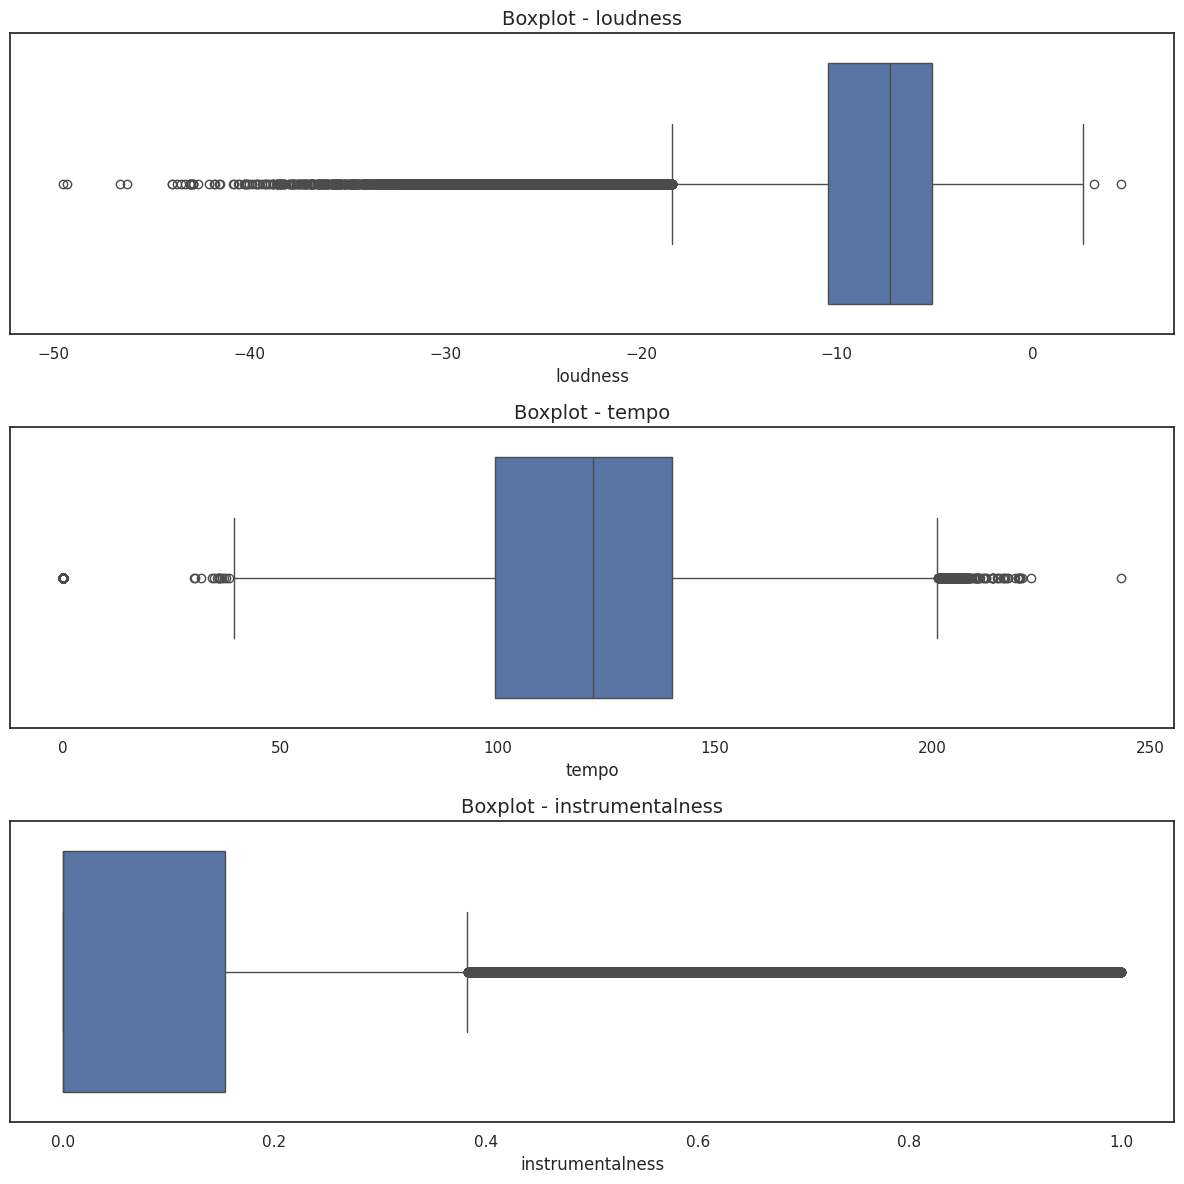

In [289]:
# Boxplot untuk mendeteksi outlier pada beberapa fitur (loudness, tempo, instrumentalness)
check_feats = [f for f in ["loudness","tempo","instrumentalness"] if f in df.columns]
plt.figure(figsize=(12,4*len(check_feats)))

for i, f in enumerate(check_feats, 1):
    plt.subplot(len(check_feats), 1, i)
    sns.boxplot(x=df[f].dropna())
    plt.title(f"Boxplot - {f}")

plt.tight_layout()
plt.show()

In [290]:
# Menampilkan contoh lagu outlier / ekstrem berdasarkan beberapa kriteria
outliers = {}

if "tempo" in df.columns:
    outliers["highest_tempo"] = df.sort_values("tempo", ascending=False).head(5)[["track_name","artists","tempo","track_genre"]]
    outliers["lowest_tempo"] = df.sort_values("tempo", ascending=True).head(5)[["track_name","artists","tempo","track_genre"]]

if "loudness" in df.columns:
    outliers["most_loud"] = df.sort_values("loudness", ascending=False).head(5)[["track_name","artists","loudness","track_genre"]]
    outliers["least_loud"] = df.sort_values("loudness", ascending=True).head(5)[["track_name","artists","loudness","track_genre"]]

if "instrumentalness" in df.columns:
    outliers["most_instrumental"] = df.sort_values("instrumentalness", ascending=False).head(5)[["track_name","artists","instrumentalness","track_genre"]]

for k,v in outliers.items():
    print(f"\n== {k.replace('_',' ').upper()} ==")
    display(v)


== HIGHEST TEMPO ==


,track_name,artists,tempo,track_genre
7133,Call The Doctor,J.J. Cale,243.372,blues
79529,Undenied,Portishead,222.605,trip-hop
22602,Hip Hip Pooh Rah,Billboard Baby Lullabies,220.525,disney
22563,Heffalumps and Woozles,Billboard Baby Lullabies,220.084,disney
1027,Makoti,Hugh Masekela,220.081,afrobeat



== LOWEST TEMPO ==


,track_name,artists,tempo,track_genre
73130,Soothing White Noise - Loopable With No Fade,White Noise Sleep Sounds,0.0,sleep
73132,Pink Noise For Sleep 2,Granular,0.0,sleep
73139,White Noise - BP 940 hz,Granular,0.0,sleep
73155,Ocean Sounds: Relaxing Wind - Loopable,The Ocean Waves Sounds,0.0,sleep
73162,Asmr: Sleepy Box Fan,ASMR HD,0.0,sleep



== MOST LOUD ==


,track_name,artists,loudness,track_genre
15201,Fate Dance,Five Star Hotel,4.532,club
45995,Islamic Capitalism,Najand,3.156,iranian
31425,Time Bomb,The Red Pears,2.574,garage
46106,A Better World Is Possible,Najand,1.864,iranian
30499,TIPO HARIEL - SEI QUE E RARIDADE -,DJ BRUNO PRADO,1.821,funk



== LEAST LOUD ==


,track_name,artists,loudness,track_genre
73130,Soothing White Noise - Loopable With No Fade,White Noise Sleep Sounds,-49.531,sleep
72797,White Noise - Loopable With No Fade,White Noise Sleep Sounds,-49.307,sleep
72972,Ceiling Fan Sound on Low Power,Atmosphere Asmr,-46.591,sleep
72624,Cricket Sound 4 - Loopable With No Fade,White Noise for Babies;Crickets;Baby Sleep Sounds,-46.251,sleep
60206,Chaconne in sol maggiore : Variazione 9,Lazar Berman,-43.957,piano



== MOST INSTRUMENTAL ==


,track_name,artists,instrumentalness,track_genre
72832,Large Industrial Air Conditioner,Sleep Baby Sleep;Baby Sleep Through the Night;...,1.0,sleep
72823,Fan Whir,Soothing White Noise for Relaxation;Sleepiciou...,1.0,sleep
72842,Brown Noise For Sleep 5,Granular,1.0,sleep
72639,Clean White Noise - Loopable with no fade,White Noise Baby Sleep;White Noise for Babies,1.0,sleep
72973,Fan Whir,White Noise for Babies;Natural White Noise for...,1.0,sleep


bisa dilihat memang ada hubungan antara tempo dan genre . misalnya tempo rendah ya wajar untuk sleep

## Data Processing

In [291]:
# kita hanya akan memilih fitur yang audio karena bersifat numerik dan merepresentasikan karakteristik musik
# Memilih fitur audio yang akan digunakan dalam model

audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

In [292]:
# Membuat dataframe baru yang hanya berisi fitur yang dibutuhkan

features_df = df[audio_features]

features_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [293]:
# Melihat statistik fitur sebelum scaling
features_df.describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
count,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000,81343.000000
mean,0.559276,0.635025,-8.593930,0.088993,0.329666,0.184733,0.219723,0.463277,122.144834
std,0.177747,0.258641,5.304797,0.116629,0.339961,0.331592,0.198272,0.263383,30.129012
min,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.446000,0.455000,-10.451500,0.036100,0.015900,0.000000,0.098500,0.241000,99.408000
50%,0.573000,0.678000,-7.262000,0.049100,0.190000,0.000089,0.133000,0.449000,122.030000
75%,0.690000,0.857000,-5.140000,0.087000,0.629000,0.153000,0.283000,0.676000,140.128500
max,0.985000,1.000000,4.532000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000


In [294]:
# Melakukan feature scaling
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_df)

In [295]:
# Mengubah hasil scaling menjadi dataframe agar lebih mudah dibaca
scaled_features_df = pd.DataFrame(
    scaled_features,
    columns=audio_features
)

scaled_features_df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.656694,-0.672849,0.348353,0.463073,-0.875005,-0.557109,0.697416,0.955736,-1.136049
1,-0.783568,-1.813434,-1.628926,-0.108831,1.748255,-0.557096,-0.598793,-0.745219,-1.482163
2,-0.682300,-1.067221,-0.214914,-0.285460,-0.352001,-0.557112,-0.518095,-1.303345,-1.520565
3,-1.649976,-2.224818,-1.870219,-0.451801,1.692365,-0.556899,-0.442441,-1.216019,1.978011
4,0.330384,-0.742444,-0.204923,-0.312041,0.409857,-0.557112,-0.690082,-1.124897,-0.072882


## Recommendation Model

### Cosine Similarity

Pada proyek ini, metode yang digunakan untuk menghitung kemiripan antar lagu adalah **Cosine Similarity**. Metode ini digunakan untuk mengukur tingkat kesamaan antara dua objek yang direpresentasikan dalam bentuk **vektor numerik**.

Dalam dataset Spotify, setiap lagu memiliki berbagai **audio features** seperti *danceability, energy, loudness, acousticness, valence,* dan *tempo*. Fitur-fitur ini dapat direpresentasikan sebagai sebuah vektor sehingga memungkinkan kita untuk membandingkan karakteristik musik antar lagu.

Cosine Similarity bekerja dengan menghitung **cosinus sudut antara dua vektor**. Semakin kecil sudut antara kedua vektor, maka semakin tinggi nilai kemiripannya.

$$
\text{Cosine Similarity}(A,B) =
\frac{A \cdot B}{\|A\| \, \|B\|}
$$

**Keterangan:**

- $A \cdot B$ adalah **dot product** antara dua vektor $A$ dan $B$.
- $\|A\|$ adalah **panjang (norma)** dari vektor $A$.
- $\|B\|$ adalah **panjang (norma)** dari vektor $B$.

Nilai Cosine Similarity berada pada rentang **-1 hingga 1**:

- **1** → kedua vektor sangat mirip  
- **0** → tidak memiliki kemiripan  
- **-1** → berlawanan arah  

Dalam konteks recommendation system, nilai yang semakin mendekati **1** menunjukkan bahwa dua lagu memiliki karakteristik audio yang semakin mirip. Oleh karena itu, lagu dengan nilai similarity tertinggi akan direkomendasikan kepada pengguna sebagai lagu yang paling relevan.

In [296]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_song(song_name, df, features, n_recommendations=10):

    # mencari index lagu
    idx = df[df["track_name"].str.lower() == song_name.lower()].index

    if len(idx) == 0:
        print("Lagu tidak ditemukan dalam dataset")
        return

    idx = idx[0]

    # mengambil vektor fitur lagu
    song_vector = features[idx].reshape(1, -1)

    # menghitung similarity dengan semua lagu
    similarity_scores = cosine_similarity(song_vector, features).flatten()

    # mengurutkan similarity tertinggi
    similar_indices = similarity_scores.argsort()[::-1]

    # mengambil top rekomendasi (kecuali lagu itu sendiri)
    similar_indices = similar_indices[1:n_recommendations+1]

    # menampilkan hasil rekomendasi
    return df.iloc[similar_indices][["track_name", "artists", "track_genre"]]

In [297]:
# kita lihat contoh lagu
df["track_name"].sample(10)

,track_name
51597,Imposible
20935,Feel Surreal Ends the Feel Surreal
54949,Beyond Control - KAS:ST Remix
50359,Nonstop
41695,Dear Mama
4520,April Rain
29694,Lalalove You
51405,Wide Awake
22335,The Dysfunctional Tango
17849,Life Soon Change


In [298]:
# contoh penggunaan dengan mencantumkan nama lagu dan rekomendasinya
# dapat dilihat bahwa tidak ada lagu yang sama dengan yang dicari
recommend_song("Bittersweet", df, scaled_features)

,track_name,artists,track_genre
10233,特別的人,Khalil Fong,cantopop
48546,CANDY,Mr.Children,j-pop
26765,Is There Still Anything That Love Can Do?,RADWIMPS,emo
32655,Bendito Serás,Toque no Altar,gospel
74022,Solamente tú,Pablo Alborán,spanish
2604,God Only Knows,for KING & COUNTRY,alt-rock
16633,Speechless,Dan + Shay,country
14266,Durga Kavach,Gundecha Brothers,classical
53281,泡沫,G.E.M.,mandopop
35144,Estou Aqui,Novo Som,groove


## Advanced Recommendation Features

Selain rekomendasi berdasarkan kemiripan lagu menggunakan Cosine Similarity,
beberapa fitur tambahan dapat ditambahkan untuk meningkatkan kegunaan sistem rekomendasi.

Fitur tambahan :

1. Rekomendasi lagu berdasarkan genre
2. Rekomendasi lagu berdasarkan artist
3. Menampilkan lagu dengan popularity tertinggi
4. Rekomendasi lagu berdasarkan mood (audio features)

### Rekomendasi Lagu Berdasarkan Genre

Fitur ini memungkinkan pengguna menemukan lagu populer dari genre tertentu.

In [299]:
def recommend_by_genre(genre, df, n_songs=10):

    genre_df = df[df["track_genre"].str.lower() == genre.lower()]

    if genre_df.empty:
        print("Genre tidak ditemukan")
        return

    genre_df = genre_df.sort_values("popularity", ascending=False)

    return genre_df[["track_name", "artists", "popularity"]].head(n_songs)

In [300]:
recommend_by_genre("pop", df)

,track_name,artists,popularity
61256,As It Was,Harry Styles,95
61276,Glimpse of Us,Joji,94
61274,Calm Down (with Selena Gomez),Rema;Selena Gomez,92
61238,Blinding Lights,The Weeknd,91
61244,Dandelions,Ruth B.,90
61242,MIDDLE OF THE NIGHT,Elley Duhé,90
61239,Starboy,The Weeknd;Daft Punk,90
61255,Until I Found You,Stephen Sanchez,90
61275,I Was Never There,The Weeknd;Gesaffelstein,90
61309,Save Your Tears,The Weeknd,89


### Rekomendasi Lagu Berdasarkan Artist

Fitur ini memungkinkan pengguna melihat lagu-lagu dari artist tertentu yang ada dalam dataset.

In [301]:
def recommend_by_artist(artist_name, df, n_songs=10):

    artist_df = df[df["artists"].str.contains(artist_name, case=False)]

    if artist_df.empty:
        print("Artist tidak ditemukan")
        return

    artist_df = artist_df.sort_values("popularity", ascending=False)

    return artist_df[["track_name", "artists", "popularity"]].head(n_songs)

In [302]:
recommend_by_artist("Taylor Swift", df)

,track_name,artists,popularity
61487,Don’t Blame Me,Taylor Swift,88
61409,august,Taylor Swift,86
61288,Blank Space,Taylor Swift,85
61426,Wildest Dreams,Taylor Swift,80
17239,I Don’t Wanna Live Forever (Fifty Shades Darker),ZAYN;Taylor Swift,80
61504,Love Story,Taylor Swift,77
27684,Renegade (feat. Taylor Swift),Big Red Machine;Taylor Swift,69
63652,Two Is Better Than One (feat. Taylor Swift),Boys Like Girls;Taylor Swift,66
16974,Highway Don't Care,Tim McGraw;Taylor Swift;Keith Urban,57
61268,You Belong With Me (Taylor’s Version),Taylor Swift,9


### Lagu dengan Popularity Tertinggi

Fitur ini menampilkan lagu-lagu dengan popularity tertinggi dalam dataset.

In [303]:
def top_popular_songs(df, n_songs=10):

    popular_df = df.sort_values("popularity", ascending=False)

    return popular_df[["track_name", "artists", "track_genre", "popularity"]].head(n_songs)

In [304]:
top_popular_songs(df)

,track_name,artists,track_genre,popularity
17152,Unholy (feat. Kim Petras),Sam Smith;Kim Petras,dance,100
41581,"Quevedo: Bzrp Music Sessions, Vol. 52",Bizarrap;Quevedo,hip-hop,99
51529,La Bachata,Manuel Turizo,latin,98
17159,I'm Good (Blue),David Guetta;Bebe Rexha,dance,98
51530,Me Porto Bonito,Bad Bunny;Chencho Corleone,latin,97
51531,Tití Me Preguntó,Bad Bunny,latin,97
51648,Efecto,Bad Bunny,latin,96
17151,Under The Influence,Chris Brown,dance,96
59742,I Ain't Worried,OneRepublic,piano,96
61256,As It Was,Harry Styles,pop,95


### Rekomendasi Lagu Berdasarkan Mood

Fitur ini memungkinkan pengguna mencari lagu berdasarkan karakteristik musik tertentu
seperti tingkat energi, danceability, dan valence.

Contoh:
- energi tinggi → lagu yang lebih upbeat
- valence tinggi → lagu yang terasa lebih positif

In [305]:
def recommend_by_mood(df, energy_level=0.8, danceability_level=0.7, n_songs=10):

    mood_df = df[
        (df["energy"] >= energy_level) &
        (df["danceability"] >= danceability_level)
    ]

    mood_df = mood_df.sort_values("popularity", ascending=False)

    return mood_df[["track_name", "artists", "energy", "danceability"]].head(n_songs)

In [306]:
recommend_by_mood(df)

,track_name,artists,energy,danceability
61274,Calm Down (with Selena Gomez),Rema;Selena Gomez,0.806,0.801
17359,Super Freaky Girl,Nicki Minaj,0.891,0.950
51756,LOKERA,Rauw Alejandro;Lyanno;Brray,0.828,0.834
17165,One Kiss (with Dua Lipa),Calvin Harris;Dua Lipa,0.862,0.791
61359,Bad Habits,Ed Sheeran,0.893,0.807
51918,La Llevo Al Cielo (Ft. Ñengo Flow),Chris Jedi;Anuel AA;Chencho Corleone;Ñengo Flow,0.845,0.795
41144,THATS WHAT I WANT,Lil Nas X,0.846,0.737
17181,Bad Decisions (with BTS & Snoop Dogg),benny blanco;BTS;Snoop Dogg,0.861,0.762
16903,You Proof,Morgan Wallen,0.850,0.731
49695,Talk that Talk,TWICE,0.907,0.772
